### Download the dataset here: [Face Mask Detection](https://www.kaggle.com/datasets/omkargurav/face-mask-dataset)

In [1]:
!curl -L -o face-mask-dataset.zip \
  https://www.kaggle.com/api/v1/datasets/download/omkargurav/face-mask-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  163M  100  163M    0     0   123M      0  0:00:01  0:00:01 --:--:--  214M


In [2]:
!unzip -qq face-mask-dataset.zip

In [4]:
import cv2

import numpy as np
from torchvision import transforms, datasets
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from PIL import Image

In [5]:
transform_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset_root = "data"
full_dataset = datasets.ImageFolder(root=dataset_root, transform=transform_pipeline)


In [6]:
print(f"Total images in dataset: {len(full_dataset)}")
print(f"Classes: {full_dataset.classes}")
print(f"Class to index mapping: {full_dataset.class_to_idx}")

Total images in dataset: 7553
Classes: ['with_mask', 'without_mask']
Class to index mapping: {'with_mask': 0, 'without_mask': 1}


In [7]:
from torch.utils.data import random_split
# calculate lengths for an 80% train and 20% test split
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

# perform the random split
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

print(f"Training samples: {len(train_dataset)}", f"Sample Structure: {train_dataset[0][0].shape}")
print(f"Test samples: {len(test_dataset)}")


Training samples: 6042 Sample Structure: torch.Size([3, 224, 224])
Test samples: 1511


In [8]:
!pip install facenet-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 105.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 810.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124

In [8]:
# import model to identify face is present in the image

import facenet_pytorch as facenet
import torch

face_detection_model = facenet.MTCNN(keep_all=True, device='cuda' if torch.cuda.is_available() else 'cpu')

In [9]:
import torch.nn as nn

from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

def get_mask_classifier(num_classes=2):
    # load the pre-trained MobileNetV2 model
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

    # replace the classifier with a new one for our task
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(model.last_channel, num_classes)
    )
    return model.to('cuda' if torch.cuda.is_available() else 'cpu')

classifier_model = get_mask_classifier(num_classes=2)


In [10]:
from torch.utils.data import DataLoader
import torch.optim as optim

# create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# define Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier_model.parameters(), lr=0.001)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 5

for epoch in range(epochs):
    classifier_model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = classifier_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")

# Save the trained weights
torch.save(classifier_model.state_dict(), 'mobilenet_mask_classifier.pth')
print("Model saved successfully")


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:981: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/5 - Loss: 0.0850
Epoch 2/5 - Loss: 0.0239
Epoch 3/5 - Loss: 0.0450
Epoch 4/5 - Loss: 0.0251
Epoch 5/5 - Loss: 0.0178
Model saved successfully


In [16]:
def predict_image(image_path, face_threshold=0.90):
    classifier_model.eval()
    pil_img = Image.open(image_path).convert('RGB')
    # detect face
    boxes, face_probs = face_detection_model.detect(pil_img)

    if boxes is None:
        print("No human faces detected in the image.")
        return
    # change class to indecx to index to class
    idx_to_class = {v: k for k, v in full_dataset.class_to_idx.items()}
    # detect boundary
    for box, f_prob in zip(boxes, face_probs):
        if f_prob < face_threshold:
            continue
        x1, y1, x2, y2 = map(int, box)
        # crop face from original image dimensions
        cropped_face = pil_img.crop((x1, y1, x2, y2))

        # transform crop for MobileNetV2
        face_tensor = transform_pipeline(cropped_face).unsqueeze(0).to(device)

        #  classify Mask via MobileNetV2
        with torch.no_grad():
            outputs = classifier_model(face_tensor)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            mask_confidence, class_id = torch.max(probabilities, dim=1)
        prediction = idx_to_class[class_id.item()]

        print(f"----------------------------------------")
        print(f"Face Boundary Box: [{x1}, {y1}, {x2}, {y2}]")
        print(f"Face Detection Confidence: {f_prob * 100:.2f}%")
        print(f"Mask Prediction Verdict: {prediction}")
        print(f"Mask Classification Confidence: {mask_confidence.item() * 100:.2f}%")
        return (x1, y1, x2, y2), prediction,f_prob * 100, mask_confidence.item() * 100

In [24]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

def visualize_prediction(image_path):
    result = predict_image(image_path)
    if result is None:
        return
    (x1, y1, x2, y2), prediction, face_confidence, mask_confidence = result
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    color = "green" if prediction.lower() == "mask" else "red"
    draw.rectangle([x1, y1, x2, y2], outline=color, width=4)
    label = f"{prediction} ({mask_confidence:.2f}%)"
    font = ImageFont.load_default()
    bbox = draw.textbbox((0, 0), label, font=font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]
    draw.rectangle([x1, y1 , x1, y1],fill=color)
    draw.text((x1 + 4, y1 - text_h - 4), label, fill="white", font=font)
    # Show image
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

In [29]:

predict_image('/content/data/with_mask/with_mask_1065.jpg')


----------------------------------------
Face Boundary Box: [-30, 12, 253, 344]
Face Detection Confidence: 99.71%
Mask Prediction Verdict: with_mask
Mask Classification Confidence: 100.00%


((-30, 12, 253, 344), 'with_mask', 99.70569610595703, 99.99665021896362)

----------------------------------------
Face Boundary Box: [-30, 12, 253, 344]
Face Detection Confidence: 99.71%
Mask Prediction Verdict: with_mask
Mask Classification Confidence: 100.00%


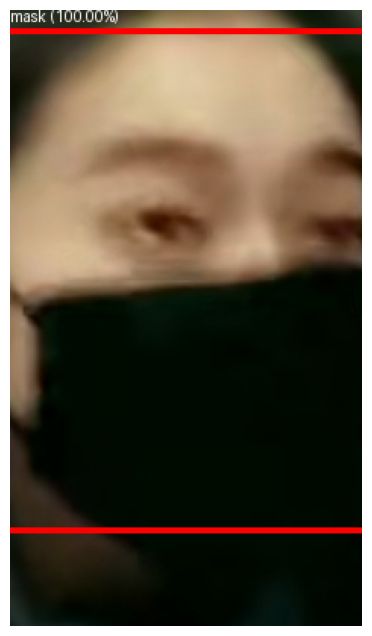

In [30]:
visualize_prediction('/content/data/with_mask/with_mask_1065.jpg')

In [22]:
predict_image("/content/data/without_mask/without_mask_1061.jpg")

----------------------------------------
Face Boundary Box: [50, 48, 178, 220]
Face Detection Confidence: 100.00%
Mask Prediction Verdict: without_mask
Mask Classification Confidence: 100.00%


((50, 48, 178, 220), 'without_mask', 99.99949932098389, 99.9998927116394)

----------------------------------------
Face Boundary Box: [50, 48, 178, 220]
Face Detection Confidence: 100.00%
Mask Prediction Verdict: without_mask
Mask Classification Confidence: 100.00%


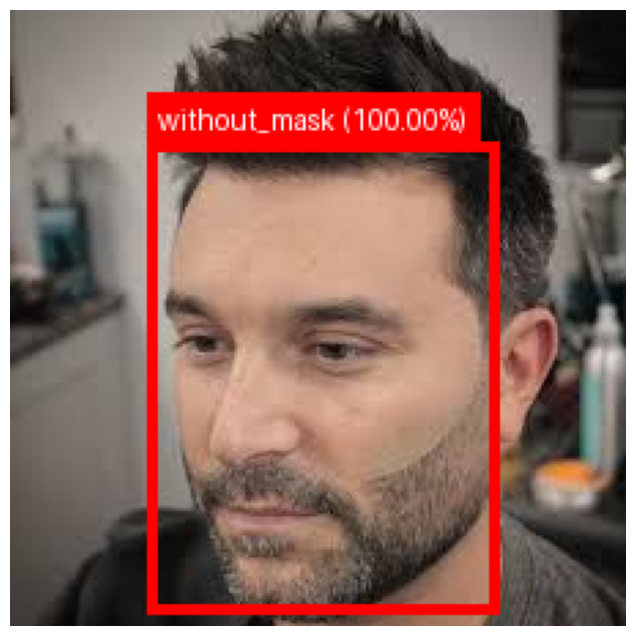

In [23]:
visualize_prediction("/content/data/without_mask/without_mask_1061.jpg")

Classification Report:
              precision    recall  f1-score   support

   with_mask       0.99      1.00      0.99       743
without_mask       1.00      0.99      0.99       768

    accuracy                           0.99      1511
   macro avg       0.99      0.99      0.99      1511
weighted avg       0.99      0.99      0.99      1511



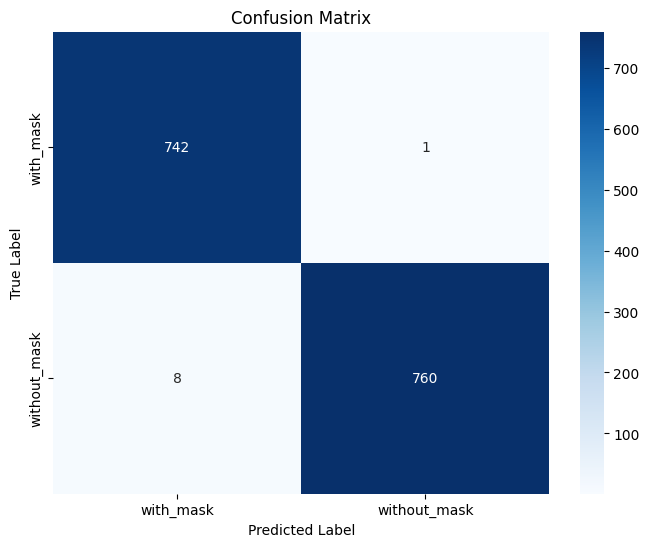

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np

classifier_model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = classifier_model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

print("Classification Report:")
print(classification_report(all_labels, all_predictions, target_names=full_dataset.classes))

conf_matrix = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [36]:
# inference speed calculation
%time result = predict_image('/content/data/with_mask/with_mask_1065.jpg')

----------------------------------------
Face Boundary Box: [-30, 12, 253, 344]
Face Detection Confidence: 99.71%
Mask Prediction Verdict: with_mask
Mask Classification Confidence: 100.00%
CPU times: user 57 ms, sys: 0 ns, total: 57 ms
Wall time: 59.6 ms


### Inference (Speed):
- CPU times: user 57 ms, sys: 0 ns, total: 57 ms
- Wall time: 59.6 ms